# 1.11 EIP-8279 Runtime BAL Meter and Demand Coupling

This notebook reconstructs the per-transaction runtime byte counter specified by [EIP-8279](https://eips.ethereum.org/EIPS/eip-8279) and uses it as the BAL quantity in the fee model.

The analysis has three tasks:

1. reconstruct and attribute the runtime counter from transaction-level protocol events for the full 6,000-block Xatu panel;
2. split metered BAL bytes into a state-linked component and an execution-linked component; and
3. define the central aggregate BAL model used by the independent-resource equilibrium calculation.

The execution-linked label denotes the remaining access-related runtime BAL represented by an execution-activity proxy; it does not claim that execution gas mechanically causes every byte. All attribution and cost-exposure results use the same 6,000-block sample.

In [1]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

START_DATE = '2026-02-01'
END_DATE = '2026-06-01'
DATE_TAG = f'{START_DATE}_{END_DATE}'
DATA_DIR = ROOT / 'data'
PLOT_DIR = ROOT / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

BLOCK_RUNTIME_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_blocks_{DATE_TAG}.csv'
STATE_EXECUTION_BLOCK_CSV = DATA_DIR / f'calibration_xatu_bal_runtime_8279_state_execution_blocks_{DATE_TAG}.csv'
BAL_PHYSICAL_BLOCK_CSV = DATA_DIR / f'calibration_bal_block_predictions_{DATE_TAG}.csv'
DAILY_ACCOUNTING_CSV = DATA_DIR / f'daily_accounting_panel_calibrated_with_bal_{DATE_TAG}.csv'
OUT_DAILY_CSV = DATA_DIR / f'calibration_bal_runtime_8279_daily_{DATE_TAG}.csv'
OUT_COMPONENTS_CSV = DATA_DIR / f'bal_runtime_8279_component_attribution_{DATE_TAG}.csv'
OUT_TWO_WAY_CSV = DATA_DIR / f'bal_runtime_8279_two_way_decomposition_{DATE_TAG}.csv'
OUT_THREE_WAY_CSV = DATA_DIR / f'bal_runtime_8279_three_way_decomposition_{DATE_TAG}.csv'
OUT_THREE_WAY_COMPONENTS_CSV = DATA_DIR / f'bal_runtime_8279_three_way_components_{DATE_TAG}.csv'
OUT_EXPOSURE_CSV = DATA_DIR / f'bal_runtime_8279_composite_cost_exposure_{DATE_TAG}.csv'
OUT_PHYSICAL_COMPARISON_CSV = DATA_DIR / f'bal_runtime_8279_physical_comparison_{DATE_TAG}.csv'
OUT_CARD_CSV = DATA_DIR / f'bal_runtime_8279_parameter_card_{DATE_TAG}.csv'
COUPLING_PLOT = PLOT_DIR / f'bal_state_creation_coupling_calibration_{DATE_TAG}.png'
THREE_WAY_COMPONENT_PLOT = PLOT_DIR / f'bal_runtime_8279_three_way_components_{DATE_TAG}.png'
DATA_COMPONENT_PLOT = PLOT_DIR / f'daily_data_resource_components_runtime_8279_{DATE_TAG}.png'

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14,
    'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
})


## Reconstructing the runtime counter

The EIP-8279 runtime counter is a deterministic weighted sum of protocol events. Xatu exposes the required cold account accesses, cold storage-key accesses, changed storage values, value-bearing calls and self-destructs, internal creations, creation endowments, and deployed code bytes. The block-level estimator is

$$
\begin{aligned}
\widehat M_i={}&
20N_{\mathrm{cold\ account},i}
+32N_{\mathrm{cold\ storage},i}
+32N_{\mathrm{changed\ value},i} \\
&+32N_{\mathrm{value\ call},i}
+32N_{\mathrm{selfdestruct},i}
+28N_{\mathrm{create},i} \\
&+32N_{\mathrm{endowed\ create},i}
+\mathrm{codeBytes}_i.
\end{aligned}
$$

Each internal `CREATE` or `CREATE2` counted by the runtime meter adds 28 bytes: 20 bytes for the new contract address and 8 bytes for its nonce. If the creation also transfers ETH to the new contract, the meter adds another 32 bytes for the contract's initial balance.

The protocol-event reconstruction, state/execution attribution, transaction-bundle split, and cost-exposure diagnostic are all run transaction by transaction over the same 6,000 sampled blocks. Transaction sums are required to reproduce the independent block-level runtime reconstruction exactly. Three sampled blocks contain no counted runtime events; they are retained as zero-BAL observations.

Xatu records cold accesses and value-bearing calls even when the surrounding call later reverts, so those EIP-8279 bytes are included. Storage writes are different: Xatu's storage-diff table contains only changes that remain after the transaction finishes. If a reverted call temporarily changes a storage value, EIP-8279 retains the 32-byte meter charge, but Xatu contains no final storage diff from which to recover it. The reconstruction therefore misses these specific reverted storage-value charges and may slightly understate the runtime counter.

The 51-byte static allowance per EIP-7702 authorization and entries covered by transaction-base headroom are not part of runtime `bal_data_bytes`. The runtime reconstruction excludes both; the daily static-data view below adds the 51-byte authorization allowance separately.

In [2]:
required = [
    BLOCK_RUNTIME_CSV, STATE_EXECUTION_BLOCK_CSV,
    BAL_PHYSICAL_BLOCK_CSV, DAILY_ACCOUNTING_CSV,
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing cached inputs:\n' + '\n'.join(missing))

runtime_blocks = pd.read_csv(BLOCK_RUNTIME_CSV)
attribution_blocks = pd.read_csv(STATE_EXECUTION_BLOCK_CSV)
bal_physical_blocks = pd.read_csv(BAL_PHYSICAL_BLOCK_CSV)
daily_accounting = pd.read_csv(DAILY_ACCOUNTING_CSV)

assert runtime_blocks['block_number'].nunique() == 6_000
assert attribution_blocks['block_number'].nunique() == 6_000
assert len(runtime_blocks) == len(attribution_blocks) == 6_000
assert (
    attribution_blocks['bal_runtime_bytes_state_8279']
    + attribution_blocks['bal_runtime_bytes_execution_8279']
    == attribution_blocks['bal_runtime_bytes_8279']
).all()
assert (
    attribution_blocks['bal_runtime_bytes_state_8279']
    + attribution_blocks['bal_runtime_bytes_coproduced_state_txs_8279']
    + attribution_blocks['bal_runtime_bytes_nonstate_txs_8279']
    == attribution_blocks['bal_runtime_bytes_8279']
).all()

validation = runtime_blocks[['block_number', 'bal_runtime_bytes_8279']].merge(
    attribution_blocks[['block_number', 'bal_runtime_bytes_8279']],
    on='block_number', how='inner', validate='one_to_one',
    suffixes=('_block', '_transaction'),
)
validation['difference'] = (
    validation['bal_runtime_bytes_8279_block']
    - validation['bal_runtime_bytes_8279_transaction']
)
assert len(validation) == 6_000
assert validation['difference'].eq(0).all()
validation_summary = pd.DataFrame([{
    'validation_blocks': len(validation),
    'exact_matches': int(validation['difference'].eq(0).sum()),
    'mean_absolute_difference_bytes': validation['difference'].abs().mean(),
}])
validation_summary

,validation_blocks,exact_matches,mean_absolute_difference_bytes
0,6000,6000,0.0


In [3]:
daily = (
    runtime_blocks.groupby('date', as_index=False)
    .agg(
        panel_blocks=('block_number', 'size'),
        bal_runtime_bytes_per_block_8279=('bal_runtime_bytes_8279', 'mean'),
    )
).merge(daily_accounting, on='date', how='left', validate='one_to_one')
daily.to_csv(OUT_DAILY_CSV, index=False)

RUNTIME_ANCHOR = np.average(
    daily['bal_runtime_bytes_per_block_8279'], weights=daily['block_count']
)
RUNTIME_DATA_GAS_16 = 16 * RUNTIME_ANCHOR
pd.DataFrame([{
    'direct_xatu_blocks': len(runtime_blocks),
    'runtime_meter_bytes_per_block': RUNTIME_ANCHOR,
    'runtime_data_gas_per_block_at_16': RUNTIME_DATA_GAS_16,
}])


,direct_xatu_blocks,runtime_meter_bytes_per_block,runtime_data_gas_per_block_at_16
0,6000,119943.743249,1.919100e+06


## Runtime-metered BAL versus final BAL RLP size

The EIP-8279 counter is the quantity priced by the data fee, but it is not the final BAL object propagated with the block. We compare both quantities on the 1,200 deterministic blocks for which exact final BAL RLP sizes are cached. This comparison is a capacity diagnostic only; the demand model continues to use runtime-metered bytes.

For the matched sample, final BAL RLP averages **134,087 bytes per block**, while the runtime counter averages **121,006 bytes**. The difference is therefore **13,080 bytes**, or **0.0131 MB**, per block. Final BAL RLP is 1.1081 times the runtime counter, but the capacity adjustment uses only the difference between them.

If $D_{\mathrm{metered}}$ includes the EIP-8279 BAL counter, then the BAL-adjusted content size is

$$
D_{\mathrm{BAL\ adjusted}}
=D_{\mathrm{metered}}-B_{\mathrm{runtime}}+B_{\mathrm{RLP}}.
$$

A 90M data-gas limit represents 5,625,000 metered-byte units, or 5.625 MB. If BAL stayed at the matched sample mean, replacing its 0.1210 MB runtime count with its 0.1341 MB final RLP would give **5.638 MB** of BAL-adjusted content. Adding the entire 0.1341 MB BAL RLP to 5.625 MB would double-count the 0.1210 MB runtime BAL already included in the metered total. The result is still not a full physical block-size bound because complete transaction envelopes and other protocol framing are excluded.


In [4]:
exact_bal_comparison = (
    bal_physical_blocks.loc[
        bal_physical_blocks['bal_source'].eq('observed_rpc'),
        ['date', 'block_number', 'bal_rlp_bytes_observed'],
    ]
    .merge(
        runtime_blocks[['block_number', 'bal_runtime_bytes_8279']],
        on='block_number', how='inner', validate='one_to_one',
    )
)
assert len(exact_bal_comparison) == 1_200
assert exact_bal_comparison['bal_rlp_bytes_observed'].notna().all()
assert exact_bal_comparison['bal_runtime_bytes_8279'].gt(0).all()

BAL_RLP_BYTES_PER_BLOCK = exact_bal_comparison['bal_rlp_bytes_observed'].mean()
BAL_RUNTIME_BYTES_PER_BLOCK = exact_bal_comparison['bal_runtime_bytes_8279'].mean()
BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK = (
    BAL_RLP_BYTES_PER_BLOCK - BAL_RUNTIME_BYTES_PER_BLOCK
)
BAL_PHYSICAL_TO_RUNTIME_RATIO = (
    exact_bal_comparison['bal_rlp_bytes_observed'].sum()
    / exact_bal_comparison['bal_runtime_bytes_8279'].sum()
)
DATA_GAS_LIMIT_EXAMPLE = 90_000_000
METERED_BYTE_CAP_EXAMPLE = DATA_GAS_LIMIT_EXAMPLE / 16
BAL_ADJUSTED_BYTE_CAP_AT_SAMPLE_MEAN = (
    METERED_BYTE_CAP_EXAMPLE + BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK
)

physical_comparison = pd.DataFrame([{
    'matched_blocks': len(exact_bal_comparison),
    'bal_rlp_bytes_per_block': BAL_RLP_BYTES_PER_BLOCK,
    'bal_runtime_bytes_8279_per_block': BAL_RUNTIME_BYTES_PER_BLOCK,
    'bal_rlp_minus_runtime_bytes_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK,
    'bal_rlp_minus_runtime_mb_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK / 1e6,
    'bal_rlp_to_runtime_ratio': BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'runtime_to_bal_rlp_ratio': 1 / BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'metered_byte_units_at_90m_data_gas': METERED_BYTE_CAP_EXAMPLE,
    'bal_adjusted_content_mb_at_90m_sample_mean_bal': (
        BAL_ADJUSTED_BYTE_CAP_AT_SAMPLE_MEAN / 1e6
    ),
}])
physical_comparison.to_csv(OUT_PHYSICAL_COMPARISON_CSV, index=False)
physical_comparison.T


,0
matched_blocks,1.200000e+03
bal_rlp_bytes_per_block,1.340865e+05
bal_runtime_bytes_8279_per_block,1.210061e+05
bal_rlp_minus_runtime_bytes_per_block,1.308041e+04
bal_rlp_minus_runtime_mb_per_block,1.308041e-02
bal_rlp_to_runtime_ratio,1.108097e+00
runtime_to_bal_rlp_ratio,9.024480e-01
metered_byte_units_at_90m_data_gas,5.625000e+06
bal_adjusted_content_mb_at_90m_sample_mean_bal,5.638080e+00


## Daily data-resource content

The daily accounting view combines static transaction content with the direct EIP-8279 runtime reconstruction. It is descriptive only: the BAL series remains behaviorally distinct from static data in the demand model.


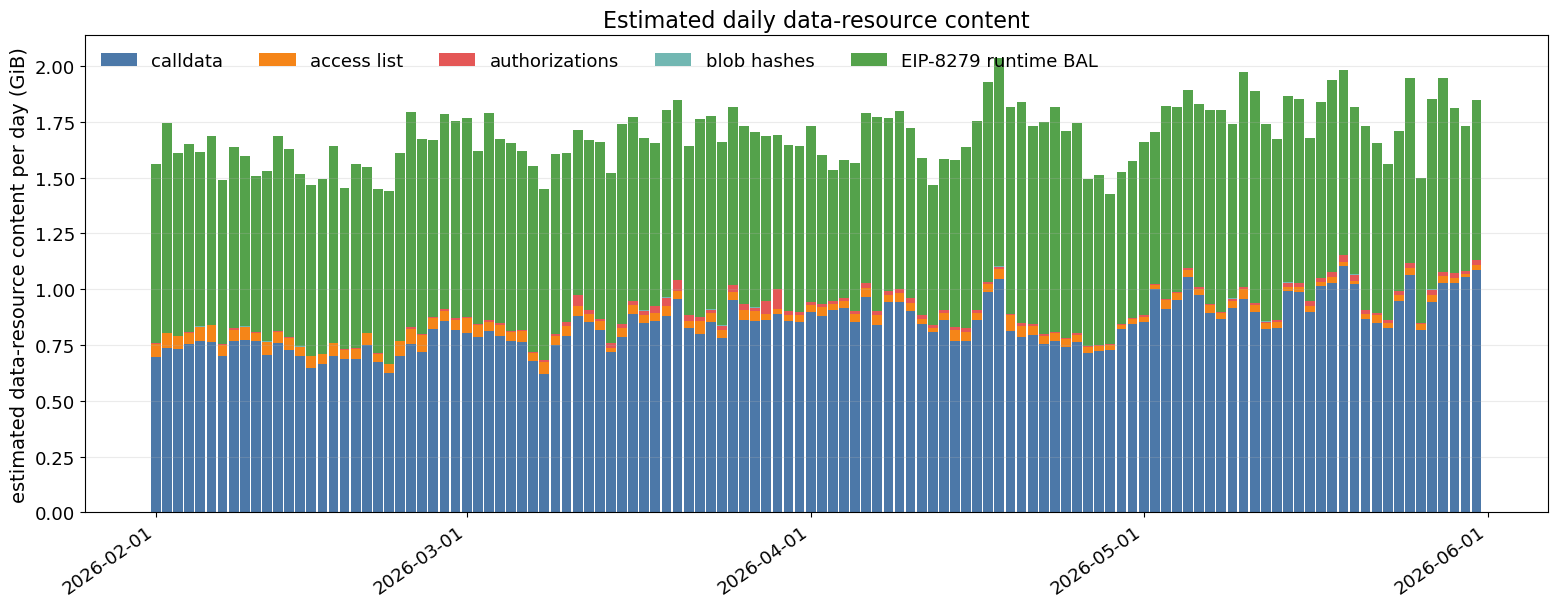

In [5]:
daily_content = daily_accounting[[
    'date', 'block_count', 'calldata_bytes', 'cal_tx_access_list_bytes',
    'cal_authorization_tuple_8131_bytes',
    'cal_authorization_tuple_count_per_block', 'blob_versioned_hash_bytes',
]].merge(
    daily[['date', 'bal_runtime_bytes_per_block_8279']],
    on='date', how='left', validate='one_to_one',
)
daily_content['runtime_bal_bytes'] = (
    daily_content['bal_runtime_bytes_per_block_8279'] * daily_content['block_count']
)
daily_content['authorization_accounted_bytes'] = (
    daily_content['cal_authorization_tuple_8131_bytes']
    + 51 * daily_content['cal_authorization_tuple_count_per_block']
    * daily_content['block_count']
)
daily_content['date'] = pd.to_datetime(daily_content['date'])
component_columns = [
    'calldata_bytes', 'cal_tx_access_list_bytes',
    'authorization_accounted_bytes', 'blob_versioned_hash_bytes',
    'runtime_bal_bytes',
]
component_labels = [
    'calldata', 'access list', 'authorizations', 'blob hashes',
    'EIP-8279 runtime BAL',
]
component_colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2', '#54a24b']
fig, ax = plt.subplots(figsize=(15.8, 6.3))
bottom = np.zeros(len(daily_content))
for column, label, color in zip(component_columns, component_labels, component_colors):
    values = daily_content[column].to_numpy(dtype=float) / 2**30
    ax.bar(daily_content['date'], values, bottom=bottom, width=0.88, color=color, label=label)
    bottom += values
ax.set_ylabel('estimated data-resource content per day (GiB)')
ax.set_title('Estimated daily data-resource content')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(frameon=False, ncol=5, loc='upper left')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(DATA_COMPONENT_PLOT, dpi=220, bbox_inches='tight')
plt.show()


## State- and execution-linked runtime BAL

The full 6,000-block transaction panel is used to separate the runtime meter into two components:

$$
M_{\mathrm{BAL}}=M_{\mathrm{state}}+M_{\mathrm{execution}}.
$$

- $M_{\mathrm{state}}$ contains runtime bytes matched directly to new storage slots, new accounts, or deployed code.
- $M_{\mathrm{execution}}$ contains the remaining runtime bytes, including existing-state access and other EIP-8279 events not matched directly to persistent state creation.

New storage slots are matched to cold storage-key and changed-value events. New accounts are matched to creation, cold-account, and value-transfer events. Deployed code is matched directly to runtime code bytes. Xatu's aggregated structlogs do not preserve the target address or storage key for each cold-access count, so cold key, account, and balance matches are capped within each transaction. The state-linked result is therefore a reproducible matched estimate rather than exact address-level attribution.

The execution suffix is model notation for the second component because total execution is used as its activity proxy. It does not mean that every byte in $M_{\mathrm{execution}}$ is mechanically generated by execution gas.

In [6]:
daily_attribution = (
    attribution_blocks.groupby('date', as_index=False)
    .agg(
        runtime_bytes=('bal_runtime_bytes_8279', 'sum'),
        state_bytes=('bal_runtime_bytes_state_8279', 'sum'),
        execution_bytes=('bal_runtime_bytes_execution_8279', 'sum'),
        sampled_blocks=('block_number', 'size'),
    )
)
daily_attribution['state_weight'] = (
    daily_attribution['state_bytes'] / daily_attribution['runtime_bytes']
)
daily_attribution['execution_weight'] = (
    daily_attribution['execution_bytes'] / daily_attribution['runtime_bytes']
)

TOTAL_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_8279'].sum())
STATE_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_state_8279'].sum())
EXECUTION_RUNTIME_BYTES = int(attribution_blocks['bal_runtime_bytes_execution_8279'].sum())
COPRODUCED_RUNTIME_BYTES = int(
    attribution_blocks['bal_runtime_bytes_coproduced_state_txs_8279'].sum()
)
NONSTATE_RUNTIME_BYTES = int(
    attribution_blocks['bal_runtime_bytes_nonstate_txs_8279'].sum()
)
STATE_WEIGHT = STATE_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
EXECUTION_WEIGHT = EXECUTION_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
COPRODUCED_WEIGHT = COPRODUCED_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
NONSTATE_WEIGHT = NONSTATE_RUNTIME_BYTES / TOTAL_RUNTIME_BYTES
STATE_BUNDLE_WEIGHT = STATE_WEIGHT + COPRODUCED_WEIGHT
TRANSACTION_COUNT = int(attribution_blocks['transactions'].sum())
STATE_TRANSACTION_COUNT = int(attribution_blocks['state_transactions'].sum())
DIRECT_STATE_TRANSACTION_COUNT = int(
    attribution_blocks['direct_state_transactions'].sum()
)
STATE_TRANSACTION_SHARE = STATE_TRANSACTION_COUNT / TRANSACTION_COUNT
DIRECT_STATE_TRANSACTION_SHARE = DIRECT_STATE_TRANSACTION_COUNT / TRANSACTION_COUNT

two_way = pd.DataFrame([
    {'component': 'state-linked', 'runtime_bytes': STATE_RUNTIME_BYTES, 'share': STATE_WEIGHT},
    {'component': 'execution-linked (access proxy)', 'runtime_bytes': EXECUTION_RUNTIME_BYTES, 'share': EXECUTION_WEIGHT},
])
two_way.to_csv(OUT_TWO_WAY_CSV, index=False)

three_way = pd.DataFrame([
    {'component': 'matched direct state', 'runtime_bytes': STATE_RUNTIME_BYTES, 'share': STATE_WEIGHT},
    {'component': 'co-produced in state-creating transactions', 'runtime_bytes': COPRODUCED_RUNTIME_BYTES, 'share': COPRODUCED_WEIGHT},
    {'component': 'transactions with no observed state creation', 'runtime_bytes': NONSTATE_RUNTIME_BYTES, 'share': NONSTATE_WEIGHT},
])
three_way.to_csv(OUT_THREE_WAY_CSV, index=False)
three_way

,component,runtime_bytes,share
0,matched direct state,81996613,0.113937
1,co-produced in state-creating transactions,272602784,0.378791
2,transactions with no observed state creation,365066264,0.507272


In [7]:
component_specs = [
    ('storage key', ['storage_key_bytes_8279'], ['direct_new_storage_key_bytes_8279']),
    ('storage value', ['storage_value_bytes_8279_observed'], ['direct_new_storage_value_bytes_8279']),
    ('account access', ['account_access_bytes_8279'], ['direct_new_account_access_bytes_8279']),
    (
        'value transfer',
        ['balance_call_bytes_8279', 'balance_selfdestruct_bytes_8279', 'create_endowment_bytes_8279'],
        ['direct_new_account_balance_bytes_8279', 'direct_create_endowment_bytes_8279'],
    ),
    (
        'contract creation',
        ['create_address_bytes_8279', 'create_nonce_bytes_8279'],
        ['direct_create_address_bytes_8279', 'direct_create_nonce_bytes_8279'],
    ),
    ('deployed code', ['deployed_code_bytes_8279'], ['direct_deployed_code_bytes_8279']),
]
component_rows = []
for component, total_columns, state_columns in component_specs:
    runtime_bytes = int(attribution_blocks[total_columns].sum().sum())
    state_bytes = int(attribution_blocks[state_columns].sum().sum())
    component_rows.append({
        'component': component,
        'runtime_bytes': runtime_bytes,
        'state_bytes': state_bytes,
        'execution_bytes': runtime_bytes - state_bytes,
        'share_of_runtime_bytes': runtime_bytes / TOTAL_RUNTIME_BYTES,
        'state_share_within_component': state_bytes / runtime_bytes if runtime_bytes else np.nan,
    })
components = pd.DataFrame(component_rows)
assert components['runtime_bytes'].sum() == TOTAL_RUNTIME_BYTES
assert components['state_bytes'].sum() == STATE_RUNTIME_BYTES
components.to_csv(OUT_COMPONENTS_CSV, index=False)

component_prefixes = {
    'storage key': 'storage_key',
    'storage value': 'storage_value',
    'account access': 'account_access',
    'value transfer': 'value_transfer',
    'contract creation': 'contract_creation',
    'deployed code': 'deployed_code',
}
three_way_component_rows = []
for component, prefix in component_prefixes.items():
    direct = int(attribution_blocks[f'{prefix}_bytes_direct_state_8279'].sum())
    coproduced = int(attribution_blocks[f'{prefix}_bytes_coproduced_state_txs_8279'].sum())
    nonstate = int(attribution_blocks[f'{prefix}_bytes_nonstate_txs_8279'].sum())
    three_way_component_rows.append({
        'component': component,
        'direct_state_bytes': direct,
        'coproduced_state_transaction_bytes': coproduced,
        'nonstate_transaction_bytes': nonstate,
        'runtime_bytes': direct + coproduced + nonstate,
    })
three_way_components = pd.DataFrame(three_way_component_rows)
for column in ['direct_state_bytes', 'coproduced_state_transaction_bytes', 'nonstate_transaction_bytes']:
    three_way_components[f'{column}_share_total'] = three_way_components[column] / TOTAL_RUNTIME_BYTES
    three_way_components[f'{column}_share_component'] = three_way_components[column] / three_way_components['runtime_bytes']
assert three_way_components['runtime_bytes'].sum() == TOTAL_RUNTIME_BYTES
assert three_way_components['direct_state_bytes'].sum() == STATE_RUNTIME_BYTES
assert three_way_components['coproduced_state_transaction_bytes'].sum() == COPRODUCED_RUNTIME_BYTES
assert three_way_components['nonstate_transaction_bytes'].sum() == NONSTATE_RUNTIME_BYTES
three_way_components.to_csv(OUT_THREE_WAY_COMPONENTS_CSV, index=False)
three_way_components

,component,direct_state_bytes,coproduced_state_transaction_bytes,nonstate_transaction_bytes,runtime_bytes,direct_state_bytes_share_total,direct_state_bytes_share_component,coproduced_state_transaction_bytes_share_total,coproduced_state_transaction_bytes_share_component,nonstate_transaction_bytes_share_total,nonstate_transaction_bytes_share_component
0,storage key,33140352,183420608,243991744,460552704,0.046050,0.071958,0.254869,0.398262,0.339035,0.529780
1,storage value,33546688,52186304,83043776,168776768,0.046614,0.198764,0.072515,0.309203,0.115392,0.492033
2,account access,974820,23523420,26638260,51136500,0.001355,0.019063,0.032687,0.460012,0.037015,0.520925
3,value transfer,3800480,13425216,11383776,28609472,0.005281,0.132840,0.018655,0.469258,0.015818,0.397902
4,contract creation,1202824,47236,8708,1258768,0.001671,0.955557,0.000066,0.037526,0.000012,0.006918
5,deployed code,9331449,0,0,9331449,0.012966,1.000000,0.000000,0.000000,0.000000,0.000000


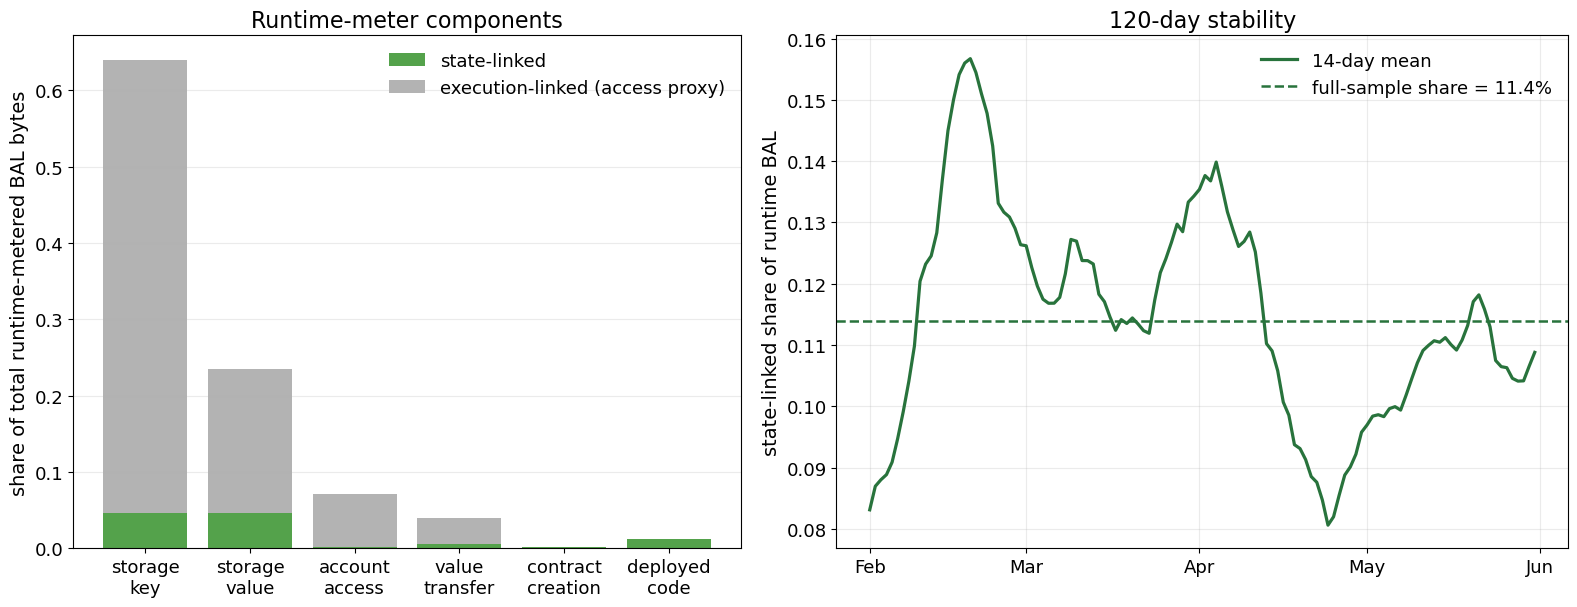

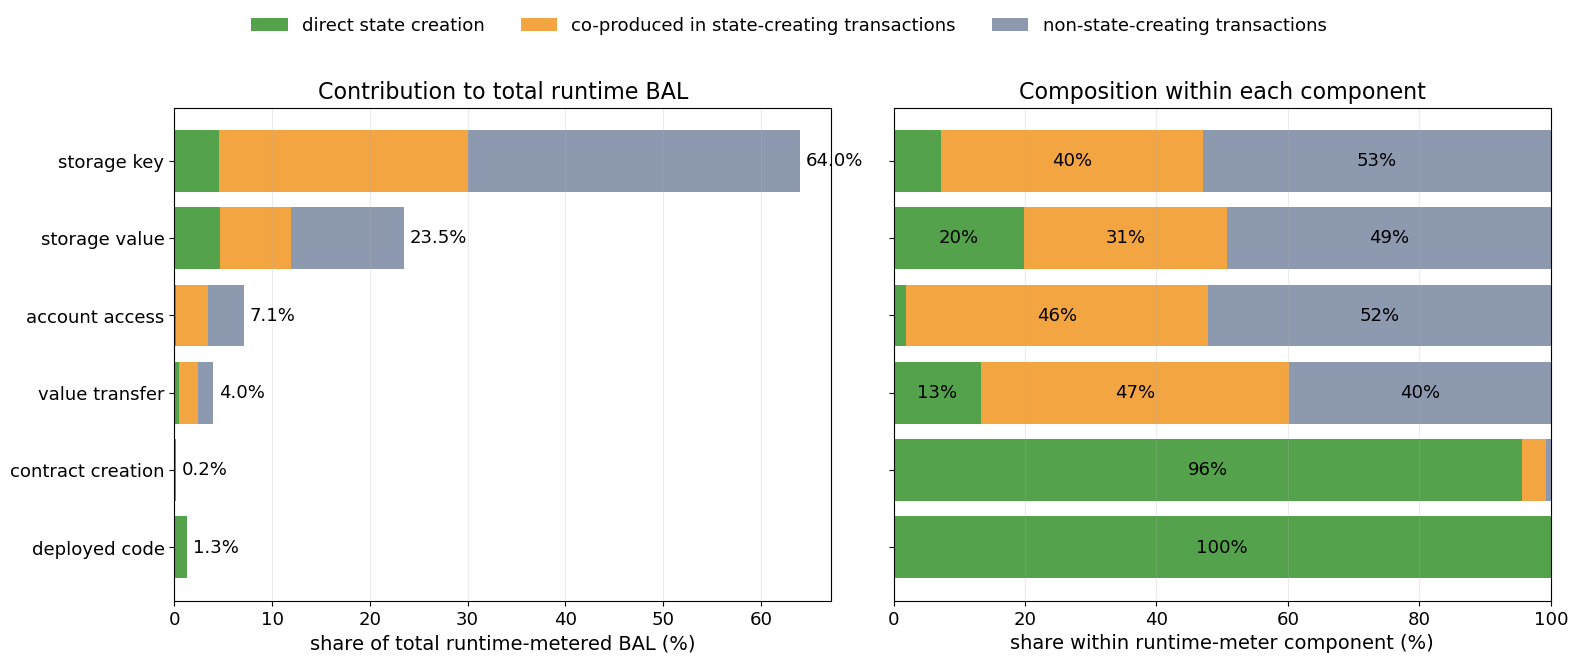

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.3), gridspec_kw={'width_ratios': [1.05, 1.15]})
x = np.arange(len(components))
state_share = components['state_bytes'] / TOTAL_RUNTIME_BYTES
execution_share = components['execution_bytes'] / TOTAL_RUNTIME_BYTES
axes[0].bar(x, state_share, color='#54a24b', label='state-linked')
axes[0].bar(
    x, execution_share, bottom=state_share, color='#b3b3b3',
    label='execution-linked (access proxy)',
)
axes[0].set_xticks(x, ['storage\nkey', 'storage\nvalue', 'account\naccess', 'value\ntransfer', 'contract\ncreation', 'deployed\ncode'])
axes[0].set_ylabel('share of total runtime-metered BAL bytes')
axes[0].set_title('Runtime-meter components')
axes[0].legend(frameon=False, loc='upper right')
axes[0].grid(axis='y', alpha=0.25)

daily_plot = daily_attribution.copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])
rolling_state = daily_plot.set_index('date')['state_weight'].rolling(
    14, center=True, min_periods=7
).mean()
axes[1].plot(rolling_state.index, rolling_state, color='#28733c', linewidth=2.3, label='14-day mean')
axes[1].axhline(
    STATE_WEIGHT, color='#28733c', linestyle='--', linewidth=1.8,
    label=f'full-sample share = {STATE_WEIGHT:.1%}',
)
axes[1].set_ylabel('state-linked share of runtime BAL')
axes[1].set_title('120-day stability')
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(COUPLING_PLOT, dpi=220, bbox_inches='tight')
plt.show()

category_columns = [
    'direct_state_bytes',
    'coproduced_state_transaction_bytes',
    'nonstate_transaction_bytes',
]
category_labels = [
    'direct state creation',
    'co-produced in state-creating transactions',
    'non-state-creating transactions',
]
category_colors = ['#54a24b', '#f2a541', '#8d99ae']
y = np.arange(len(three_way_components))
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.6), sharey=True)

left = np.zeros(len(three_way_components))
for column, label, color in zip(category_columns, category_labels, category_colors):
    values = 100 * three_way_components[column] / TOTAL_RUNTIME_BYTES
    axes[0].barh(y, values, left=left, color=color, label=label)
    left += values
for row, total_share in enumerate(left):
    axes[0].text(total_share + 0.6, row, f'{total_share:.1f}%', va='center', fontsize=13)
axes[0].set_xlabel('share of total runtime-metered BAL (%)')
axes[0].set_title('Contribution to total runtime BAL')
axes[0].set_yticks(y, three_way_components['component'])
axes[0].grid(axis='x', alpha=0.25)

left = np.zeros(len(three_way_components))
for column, label, color in zip(category_columns, category_labels, category_colors):
    values = 100 * three_way_components[column] / three_way_components['runtime_bytes']
    axes[1].barh(y, values, left=left, color=color, label=label)
    for row, (start, value) in enumerate(zip(left, values)):
        if value >= 8:
            axes[1].text(start + value / 2, row, f'{value:.0f}%', ha='center', va='center', fontsize=13)
    left += values
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('share within runtime-meter component (%)')
axes[1].set_title('Composition within each component')
axes[1].grid(axis='x', alpha=0.25)
axes[0].invert_yaxis()
fig.legend(*axes[1].get_legend_handles_labels(), frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(THREE_WAY_COMPONENT_PLOT, dpi=220, bbox_inches='tight')
plt.show()

## Central BAL demand model

Let $B_t$ denote EIP-8279 runtime-metered BAL bytes, $S_t$ persistent state-creation activity, and $A_t$ existing-state access activity. Define $w_{\mathrm{state}}$ and $w_{\mathrm{execution}}=1-w_{\mathrm{state}}$ as the two runtime-meter weights. The central model is

$$
\frac{B_t}{B_0}
=w_{\mathrm{state}}\frac{S_t}{S_0}
+w_{\mathrm{execution}}\frac{A_t}{A_0}.
$$

The 6,000-block estimates are $w_{\mathrm{state}}=0.113937$ and $w_{\mathrm{execution}}=0.886063$.

The wider historical panel does not contain an independently priced state-access quantity. Total execution activity is therefore used as a proxy:

$$
\frac{A_t}{A_0}
\approx
\left(\frac{E_t}{E_0}\right)^{\rho_A},
\qquad \rho_A=1.
$$

The central benchmark is therefore

$$
\frac{B_t}{B_0}
=0.113937\frac{S_t}{S_0}
+0.886063\frac{E_t}{E_0}.
$$

The execution-linked component is not empirically shown to follow execution demand. Total execution is a reduced-form proxy for state-access activity, and $\rho_A=1$ assumes that access intensity remains constant as execution scales.

The same 6,000-block panel provides a transaction-bundle diagnostic. Directly matched state creation contributes 11.39% of runtime BAL, access co-produced inside state-creating transactions contributes 37.88%, and transactions with no observed state creation contribute 50.73%. If $\lambda$ is the share of co-produced access assigned to state activity, then

$$
w_{\mathrm{state}}(\lambda)=0.113937+0.378791\lambda.
$$

The central model sets $\lambda=0$, so only bytes directly matched to created objects follow $S_t$. The co-produced pool establishes exposure to state-creating transactions, not its behavioral response to the state fee; the aggregate state elasticity does not identify how those transaction bundles exit.

The model also sets $\gamma_{\mathrm{BAL}}=0$. BAL responds through its parent state-creation and access activities rather than through an additional direct response to the data fee. This is an assumption for the current aggregate model, not an estimated zero elasticity.

In [9]:
GAMMA_BAL_CENTRAL = 0.0
RHO_ACCESS_CENTRAL = 1.0
central_model = pd.DataFrame([{
    'state_weight': STATE_WEIGHT,
    'execution_weight': EXECUTION_WEIGHT,
    'gamma_bal_data_price': GAMMA_BAL_CENTRAL,
    'rho_access_execution_proxy': RHO_ACCESS_CENTRAL,
    'coproduced_state_transaction_weight': COPRODUCED_WEIGHT,
    'nonstate_transaction_weight': NONSTATE_WEIGHT,
    'lambda_coproduced_to_state': 0.0,
}])
central_model

,state_weight,execution_weight,gamma_bal_data_price,rho_access_execution_proxy,coproduced_state_transaction_weight,nonstate_transaction_weight,lambda_coproduced_to_state
0,0.113937,0.886063,0.0,1.0,0.378791,0.507272,0.0


## Appendix: Transaction-cost exposure diagnostic

At normalized anchor prices, each transaction's execution, data, and state cost shares are weighted by its EIP-8279 runtime bytes. This diagnostic uses the same 6,000 blocks as the attribution. Execution dominates the normalized cost of BAL-producing transactions, but cost shares do not identify transaction exit elasticities and are not used to set the central BAL-demand coefficients. Transaction-level access-list, authorization, and blob-hash fields are unavailable in the joined panel and are omitted.


In [10]:
exposure = pd.DataFrame({
    'resource': ['execution', 'data', 'state'],
    'bal_weighted_cost_exposure': [
        attribution_blocks['runtime_x_execution_cost_share'].sum() / TOTAL_RUNTIME_BYTES,
        attribution_blocks['runtime_x_data_cost_share'].sum() / TOTAL_RUNTIME_BYTES,
        attribution_blocks['runtime_x_state_cost_share'].sum() / TOTAL_RUNTIME_BYTES,
    ],
})
exposure.to_csv(OUT_EXPOSURE_CSV, index=False)

LAMBDA_COST_WEIGHTED = (
    attribution_blocks['coproduced_x_state_cost_share'].sum()
    / COPRODUCED_RUNTIME_BYTES
)
COST_WEIGHTED_STATE_WEIGHT = STATE_WEIGHT + COPRODUCED_WEIGHT * LAMBDA_COST_WEIGHTED
display(exposure)
pd.DataFrame([{
    'cost_weighted_lambda': LAMBDA_COST_WEIGHTED,
    'illustrative_cost_weighted_state_weight': COST_WEIGHTED_STATE_WEIGHT,
}])


,resource,bal_weighted_cost_exposure
0,execution,0.804608
1,data,0.078290
2,state,0.117102


,cost_weighted_lambda,illustrative_cost_weighted_state_weight
0,0.157287,0.173516


In [11]:
WHOLE_KAPPA = exposure.set_index('resource')['bal_weighted_cost_exposure'].to_dict()

card = pd.DataFrame([{
    'runtime_meter_spec': 'EIP-8279 bal_data_bytes reconstructed from Xatu protocol events',
    'runtime_anchor_blocks': len(runtime_blocks),
    'runtime_transaction_attribution_blocks': len(attribution_blocks),
    'runtime_cost_diagnostic_blocks': len(attribution_blocks),
    'runtime_block_transaction_exact_match_share': validation['difference'].eq(0).mean(),
    'bal_runtime_bytes_per_block_8279': RUNTIME_ANCHOR,
    'bal_runtime_data_gas_per_block_at_16': RUNTIME_DATA_GAS_16,
    'physical_bal_comparison_blocks': len(exact_bal_comparison),
    'bal_rlp_to_runtime_ratio': BAL_PHYSICAL_TO_RUNTIME_RATIO,
    'bal_rlp_minus_runtime_bytes_per_block': BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK,
    'bal_adjusted_content_mb_at_90m_sample_mean_bal': physical_comparison.loc[0, 'bal_adjusted_content_mb_at_90m_sample_mean_bal'],
    'state_linked_runtime_weight_8279': STATE_WEIGHT,
    'execution_linked_runtime_weight_8279': EXECUTION_WEIGHT,
    'coproduced_state_transaction_runtime_weight_8279': COPRODUCED_WEIGHT,
    'nonstate_transaction_runtime_weight_8279': NONSTATE_WEIGHT,
    'state_creating_transaction_share': STATE_TRANSACTION_SHARE,
    'direct_state_matched_transaction_share': DIRECT_STATE_TRANSACTION_SHARE,
    'whole_bal_kappa_execution': WHOLE_KAPPA['execution'],
    'whole_bal_kappa_data': WHOLE_KAPPA['data'],
    'whole_bal_kappa_state': WHOLE_KAPPA['state'],
    'cost_weighted_coproduced_lambda': LAMBDA_COST_WEIGHTED,
    'illustrative_cost_weighted_state_weight': COST_WEIGHTED_STATE_WEIGHT,
    'central_gamma_bal_data_price': GAMMA_BAL_CENTRAL,
    'central_rho_access_execution_proxy': RHO_ACCESS_CENTRAL,
    'central_effective_state_weight': STATE_WEIGHT,
    'central_effective_execution_weight': EXECUTION_WEIGHT,
    'state_attribution_status': 'transaction-level matched proxy; cold key/account/balance matches capped within transaction',
    'composite_cost_proxy_status': 'normalized anchor fees; 6,000-block transaction aggregates',
    'meter_reconstruction_status': 'Xatu observed path; reverted-frame storage-value bytes unavailable',
}])
card.to_csv(OUT_CARD_CSV, index=False)

assert np.isclose(STATE_WEIGHT + EXECUTION_WEIGHT, 1.0)
assert np.isclose(STATE_WEIGHT + COPRODUCED_WEIGHT + NONSTATE_WEIGHT, 1.0)
assert 0.10 < STATE_WEIGHT < 0.14
assert np.isclose(sum(WHOLE_KAPPA.values()), 1.0)
assert GAMMA_BAL_CENTRAL == 0
assert RHO_ACCESS_CENTRAL == 1
assert 115_000 < RUNTIME_ANCHOR < 125_000
assert 1.05 < BAL_PHYSICAL_TO_RUNTIME_RATIO < 1.20
assert 10_000 < BAL_RLP_MINUS_RUNTIME_BYTES_PER_BLOCK < 20_000
assert runtime_blocks['bal_runtime_bytes_8279'].ge(0).all()

display(card.T)
print(OUT_DAILY_CSV)
print(OUT_COMPONENTS_CSV)
print(OUT_TWO_WAY_CSV)
print(OUT_THREE_WAY_CSV)
print(OUT_THREE_WAY_COMPONENTS_CSV)
print(OUT_EXPOSURE_CSV)
print(OUT_PHYSICAL_COMPARISON_CSV)
print(OUT_CARD_CSV)
print(COUPLING_PLOT)
print(THREE_WAY_COMPONENT_PLOT)
print(DATA_COMPONENT_PLOT)

,0
runtime_meter_spec,EIP-8279 bal_data_bytes reconstructed from Xat...
runtime_anchor_blocks,6000
runtime_transaction_attribution_blocks,6000
runtime_cost_diagnostic_blocks,6000
runtime_block_transaction_exact_match_share,1.0
bal_runtime_bytes_per_block_8279,119943.743249
bal_runtime_data_gas_per_block_at_16,1919099.891982
physical_bal_comparison_blocks,1200
bal_rlp_to_runtime_ratio,1.108097
bal_rlp_minus_runtime_bytes_per_block,13080.413333


/Users/william/PycharmProjects/eip-7999-research/data/calibration_bal_runtime_8279_daily_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_component_attribution_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_two_way_decomposition_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_three_way_decomposition_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_three_way_components_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_composite_cost_exposure_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_physical_comparison_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/data/bal_runtime_8279_parameter_card_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/plots/bal